Install Packages

In [17]:
!python -m pip install -qq pandas xarray matplotlib netcdf4 pyproj pyrsig pycno

Import Packages

In [18]:
# Import Libraries
import pyproj
import xarray as xr
import pyrsig
import pandas as pd
import pycno
import getpass
import matplotlib.pyplot as plt

Set location name, spatial extent, and time interval

In [19]:
grid = dict(
    GDNAM='GLOBAL', GDTYP=1, NCOLS=7200, NROWS=3600,
    XORIG=-125, YORIG=20, XCELL=0.01, YCELL=0.01,
    P_ALP=0., P_BET=0., P_GAM=0., XCENT=0., YCENT=0.
)

In [20]:
locname = 'HRBT'
bbox = (-76.93, 36.55, -75.86, 37.37)
bdate = '2024-09-11 10:00:00'
edate = '2024-09-12 19:00:00'

Use Api to get Tempo data

In [21]:
api = pyrsig.RsigApi(bdate=bdate, bbox=bbox, edate=edate, workdir=locname, gridfit=True, grid_kw = grid) #grid_kw = 'global_0pt1') #grid_kw = '1US1')
#api = pyrsig.RsigApi(bdate=bdate, bbox=bbox, workdir=locname, gridfit=True, grid_kw = '1US1')
#api_key = getpass.getpass('Enter TEMPO key (anonymous if unknown):')
api_key = 'anonymous'  # using public, so using anonymous
api.tempo_kw['api_key'] = api_key

In [22]:
print(grid)

{'GDNAM': 'GLOBAL', 'GDTYP': 1, 'NCOLS': 7200, 'NROWS': 3600, 'XORIG': -125, 'YORIG': 20, 'XCELL': 0.01, 'YCELL': 0.01, 'P_ALP': 0.0, 'P_BET': 0.0, 'P_GAM': 0.0, 'XCENT': 0.0, 'YCENT': 0.0, 'VGTYP': 7, 'VGTOP': 5000.0, 'NLAYS': 35, 'earth_radius': 6370000.0, 'g': 9.81, 'R': 287.04, 'A': 50.0, 'T0': 290, 'P0': 100000.0, 'REGRID_AGGREGATE': 'None', 'REGRID': 'weighted'}


In [23]:
# after the cell runs, click on the table button.
# Then use filters to find tempo data producs by names that start with tempo
descdf = api.descriptions()
descdf
descdf.query('name.str.contains("tempo.l2.no2.vertical_column_troposphere")')

,name,label,description,bbox_str,beginPosition,timeResolution,endPosition,prefix
5745,tempo.l2.no2.vertical_column_troposphere,l2.no2.vertical_column_troposphere(molecules/cm2),Troposphere nitrogen dioxide vertical column.,-180 -90 180 90,2023-08-02T00:00:00Z,PT1Y,now,tempo
5746,tempo.l2.no2.vertical_column_troposphere_uncer...,l2.no2.vertical_column_troposphere_uncertainty...,Troposphere nitrogen dioxide vertical column u...,-180 -90 180 90,2023-08-02T00:00:00Z,PT1Y,now,tempo


In [24]:
tempokey = 'tempo.l2.no2.vertical_column_troposphere' #tempo key

In [25]:
tropkey = 'tropomi.offl.no2.nitrogendioxide_tropospheric_column' # This is the tropomi api key

In [26]:
# By default, the pyrsig uses 'ascii' backend, but 'xdr' is faster;
# both look the same in python, but the files are very different.
# I'm using xdr here for speed
df = api.to_dataframe(tempokey, backend='xdr')
#df = api.to_dataframe(tempokey)
df

Using cached: HRBT/tempo.l2.no2.vertical_column_troposphere_2024-09-11T100000Z_2024-09-12T190000Z.xdr.gz


,Timestamp(UTC),LONGITUDE(deg),LATITUDE(deg),no2_vertical_column_troposphere(molecules/cm2),Longitude_SW(deg),Longitude_SE(deg),Longitude_NW(deg),Longitude_NE(deg),Latitude_SW(deg),Latitude_SE(deg),Latitude_NW(deg),Latitude_NE(deg)
0,2024-09-11T12:38:00+0000,-76.767990,37.368706,3.360201e+15,-76.737080,-76.794188,-76.741426,-76.798523,37.379294,37.377800,37.359850,37.358350
1,2024-09-11T12:38:00+0000,-76.824730,37.367428,1.510950e+15,-76.794188,-76.850824,-76.798523,-76.855154,37.377800,37.376202,37.358350,37.356728
2,2024-09-11T12:38:00+0000,-76.881248,37.365505,6.826231e+13,-76.850824,-76.908407,-76.855154,-76.912712,37.376202,37.373820,37.356728,37.354354
3,2024-09-11T12:38:00+0000,-76.085014,37.369099,2.532131e+15,-76.053946,-76.111137,-76.058523,-76.115696,37.379928,37.378005,37.360456,37.358535
4,2024-09-11T12:38:00+0000,-76.141823,37.367435,1.965112e+15,-76.111137,-76.168612,-76.115696,-76.173153,37.378005,37.376369,37.358535,37.356900
...,...,...,...,...,...,...,...,...,...,...,...,...
643,2024-09-12T19:47:00+0000,-75.870468,36.557667,1.768881e+15,-75.839958,-75.896681,-75.844381,-75.901089,36.568261,36.566630,36.549109,36.547477
644,2024-09-12T19:47:00+0000,-75.927307,36.556427,2.008229e+15,-75.896681,-75.953587,-75.901089,-75.957975,36.566630,36.565028,36.547477,36.545878
645,2024-09-12T19:47:00+0000,-75.984253,36.554474,2.010840e+15,-75.953587,-76.010429,-75.957975,-76.014799,36.565028,36.563357,36.545878,36.544209
646,2024-09-12T19:47:00+0000,-76.040977,36.553085,1.985508e+15,-76.010429,-76.066637,-76.014799,-76.070984,36.563357,36.561666,36.544209,36.542524


In [27]:
# Do it again, but cleanup the keys and add time object
# Notice that the file is reused
df = api.to_dataframe(tempokey, unit_keys=False, parse_dates=True, backend='xdr')
df

Using cached: HRBT/tempo.l2.no2.vertical_column_troposphere_2024-09-11T100000Z_2024-09-12T190000Z.xdr.gz


,Timestamp,LONGITUDE,LATITUDE,no2_vertical_column_troposphere,Longitude_SW,Longitude_SE,Longitude_NW,Longitude_NE,Latitude_SW,Latitude_SE,Latitude_NW,Latitude_NE,time
0,2024-09-11T12:38:00+0000,-76.767990,37.368706,3.360201e+15,-76.737080,-76.794188,-76.741426,-76.798523,37.379294,37.377800,37.359850,37.358350,2024-09-11 12:38:00+00:00
1,2024-09-11T12:38:00+0000,-76.824730,37.367428,1.510950e+15,-76.794188,-76.850824,-76.798523,-76.855154,37.377800,37.376202,37.358350,37.356728,2024-09-11 12:38:00+00:00
2,2024-09-11T12:38:00+0000,-76.881248,37.365505,6.826231e+13,-76.850824,-76.908407,-76.855154,-76.912712,37.376202,37.373820,37.356728,37.354354,2024-09-11 12:38:00+00:00
3,2024-09-11T12:38:00+0000,-76.085014,37.369099,2.532131e+15,-76.053946,-76.111137,-76.058523,-76.115696,37.379928,37.378005,37.360456,37.358535,2024-09-11 12:38:00+00:00
4,2024-09-11T12:38:00+0000,-76.141823,37.367435,1.965112e+15,-76.111137,-76.168612,-76.115696,-76.173153,37.378005,37.376369,37.358535,37.356900,2024-09-11 12:38:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,2024-09-12T19:47:00+0000,-75.870468,36.557667,1.768881e+15,-75.839958,-75.896681,-75.844381,-75.901089,36.568261,36.566630,36.549109,36.547477,2024-09-12 19:47:00+00:00
644,2024-09-12T19:47:00+0000,-75.927307,36.556427,2.008229e+15,-75.896681,-75.953587,-75.901089,-75.957975,36.566630,36.565028,36.547477,36.545878,2024-09-12 19:47:00+00:00
645,2024-09-12T19:47:00+0000,-75.984253,36.554474,2.010840e+15,-75.953587,-76.010429,-75.957975,-76.014799,36.565028,36.563357,36.545878,36.544209,2024-09-12 19:47:00+00:00
646,2024-09-12T19:47:00+0000,-76.040977,36.553085,1.985508e+15,-76.010429,-76.066637,-76.014799,-76.070984,36.563357,36.561666,36.544209,36.542524,2024-09-12 19:47:00+00:00


In [28]:
# Make an hourly average
hdf = df.groupby(pd.Grouper(key='time', freq='1h')).mean(numeric_only=True)
hdf

,LONGITUDE,LATITUDE,no2_vertical_column_troposphere,Longitude_SW,Longitude_SE,Longitude_NW,Longitude_NE,Latitude_SW,Latitude_SE,Latitude_NW,Latitude_NE
time,,,,,,,,,,,
2024-09-11 12:00:00+00:00,-76.393868,36.958311,3.094661e+15,-76.363229,-76.420129,-76.367611,-76.424493,36.968823,36.967098,36.949519,36.947795
2024-09-11 13:00:00+00:00,-76.395478,36.958392,2.933441e+15,-76.364734,-76.421848,-76.369109,-76.426205,36.968891,36.967207,36.949584,36.947902
2024-09-11 14:00:00+00:00,-76.395050,36.958315,2.655239e+15,-76.364300,-76.421432,-76.368664,-76.425778,36.968828,36.967118,36.949522,36.947815
2024-09-11 15:00:00+00:00,-76.396374,36.959102,2.408999e+15,-76.365835,-76.422555,-76.370191,-76.426892,36.969606,36.967906,36.950303,36.948605
2024-09-11 16:00:00+00:00,-76.392009,36.958724,2.447290e+15,-76.361485,-76.418168,-76.365837,-76.422501,36.969235,36.967521,36.949935,36.948223
2024-09-11 17:00:00+00:00,-76.389793,36.966090,2.627489e+15,-76.359293,-76.415936,-76.363643,-76.420268,36.976585,36.974900,36.957285,36.955603
2024-09-11 18:00:00+00:00,-76.389723,36.965327,2.581489e+15,-76.359228,-76.415864,-76.363575,-76.420192,36.975821,36.974133,36.956525,36.954839
2024-09-11 19:00:00+00:00,-76.387257,36.966044,2.907640e+15,-76.356852,-76.413306,-76.361197,-76.417633,36.976544,36.974845,36.957251,36.955553
2024-09-11 20:00:00+00:00,-76.392118,36.962693,2.671835e+15,-76.361697,-76.418194,-76.366038,-76.422516,36.973176,36.971508,36.953885,36.952219


<Axes: title={'center': 'TEMPO'}, xlabel='Time (UTC)', ylabel='NO2 (molec/cm2)'>

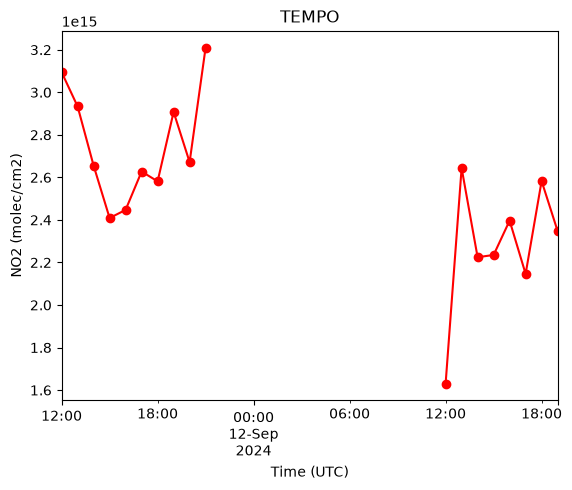

In [29]:
# Plot a data column selected from the names above, Date in title if desired
tempocol = 'no2_vertical_column_troposphere'
tx = hdf[tempocol]
tx.plot(ylabel='NO2 (molec/cm2)', title = 'TEMPO', xlabel='Time (UTC)', color='r',marker='o')

In [30]:
tx.to_csv('TEMPO'+'_'+bdate[:10]+'_'+edate[:10]+bdate[11:13]+'h'+'_'+edate[11:13]+'h'+'.csv',index=True, mode = 'w')

In [31]:
tf = api.to_dataframe(tropkey, unit_keys=False, parse_dates=True, backend='xdr')
tf

Using cached: HRBT/tropomi.offl.no2.nitrogendioxide_tropospheric_column_2024-09-11T100000Z_2024-09-12T190000Z.xdr.gz


,Timestamp,LONGITUDE,LATITUDE,nitrogendioxide_tropospheric_column,Longitude_SW,Longitude_SE,Longitude_NW,Longitude_NE,Latitude_SW,Latitude_SE,Latitude_NW,Latitude_NE,time
0,2024-09-11T17:57:00+0000,-75.902725,36.550671,1.883041e+15,-75.915236,-75.873516,-75.932005,-75.890261,36.520856,36.531770,36.569542,36.580461,2024-09-11 17:57:00+00:00
1,2024-09-11T17:57:00+0000,-75.861038,36.561550,2.009223e+15,-75.873516,-75.831892,-75.890261,-75.848610,36.531770,36.542613,36.580461,36.591308,2024-09-11 17:57:00+00:00
2,2024-09-11T17:57:00+0000,-76.087334,36.555099,8.537337e+14,-76.100006,-76.057848,-76.116879,-76.074696,36.525134,36.536347,36.573810,36.585028,2024-09-11 17:57:00+00:00
3,2024-09-11T17:57:00+0000,-76.045219,36.566277,1.029452e+15,-76.057848,-76.015797,-76.074696,-76.032618,36.536347,36.547486,36.585028,36.596171,2024-09-11 17:57:00+00:00
4,2024-09-11T17:57:00+0000,-76.003204,36.577381,1.897416e+15,-76.015797,-75.973848,-76.032618,-75.990644,36.547486,36.558551,36.596171,36.607240,2024-09-11 17:57:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2024-09-12T17:38:00+0000,-76.177109,37.349968,8.564042e+14,-76.199245,-76.135059,-76.219423,-76.155201,37.314136,37.337676,37.362102,37.385653,2024-09-12 17:38:00+00:00
122,2024-09-12T17:38:00+0000,-76.592247,37.251305,1.360977e+15,-76.615944,-76.548470,-76.636354,-76.568844,37.214608,37.239957,37.262482,37.287844,2024-09-12 17:38:00+00:00
123,2024-09-12T17:38:00+0000,-76.525047,37.276501,1.665259e+15,-76.548470,-76.481565,-76.568844,-76.501904,37.239957,37.264992,37.287844,37.312891,2024-09-12 17:38:00+00:00
124,2024-09-12T17:38:00+0000,-76.458405,37.301388,1.511906e+15,-76.481565,-76.415220,-76.501904,-76.435522,37.264992,37.289718,37.312891,37.337628,2024-09-12 17:38:00+00:00


In [32]:
tdf = tf.groupby(pd.Grouper(key='time', freq='1h')).mean(numeric_only=True)
tdf

,LONGITUDE,LATITUDE,nitrogendioxide_tropospheric_column,Longitude_SW,Longitude_SE,Longitude_NW,Longitude_NE,Latitude_SW,Latitude_SE,Latitude_NW,Latitude_NE
time,,,,,,,,,,,
2024-09-11 17:00:00+00:00,-76.320192,37.006786,1.595330e+15,-76.332992,-76.290368,-76.350094,-76.307444,36.976745,36.988145,37.025385,37.036790
2024-09-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-11 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-12 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-12 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'TROMPOMI'}, xlabel='Time (UTC)', ylabel='NO2 (molec/cm2)'>

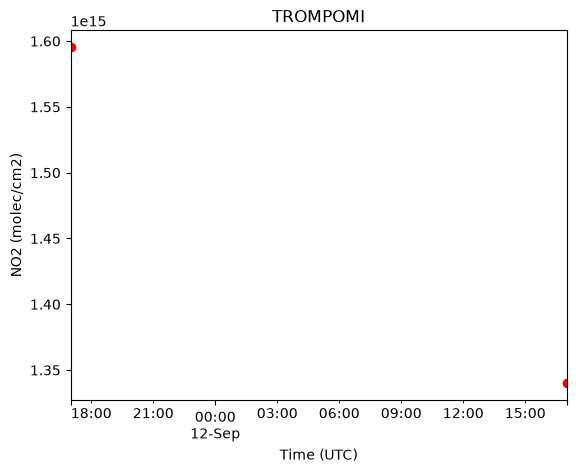

In [33]:
tropcol = 'nitrogendioxide_tropospheric_column'
trox = tdf[tropcol]
trox.plot(ylabel='NO2 (molec/cm2)', title = 'TROMPOMI', xlabel='Time (UTC)', color='r',marker='o')

In [34]:
trox.to_csv('TROPOMI'+'_'+bdate[:10]+'_'+edate[:10]+bdate[11:13]+'h'+'_'+edate[11:13]+'h'+'.csv',index=True, mode = 'w')

0      3.360201e+15
1      1.510950e+15
2      6.826231e+13
3      2.532131e+15
4      1.965112e+15
           ...     
643    1.768881e+15
644    2.008229e+15
645    2.010840e+15
646    1.985508e+15
647    2.594424e+15
Name: no2_vertical_column_troposphere, Length: 13638, dtype: float64


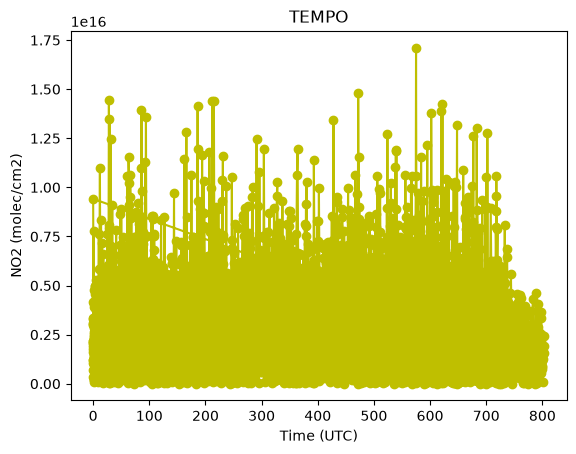

In [35]:
nx=df[tempocol]
nx.plot(ylabel='NO2 (molec/cm2)', title = 'TEMPO', xlabel='Time (UTC)', color='y',marker='o')
None
print(nx)

Use Api to get Airnow Data

In [36]:
airnowkey = 'airnow.no2'
adf = api.to_dataframe(airnowkey, unit_keys=False, parse_dates=True)
adf

,Timestamp,LONGITUDE,LATITUDE,STATION,no2,SITE_NAME,time
0,2024-09-11T10:00:00-0000,-76.38702,37.10373,9843,7.8,840516500008;42602;qc:0,2024-09-11 10:00:00+00:00
1,2024-09-11T10:00:00-0000,-76.30135,36.85555,9845,26.2,840517100024;42602;qc:0,2024-09-11 10:00:00+00:00
2,2024-09-11T11:00:00-0000,-76.38702,37.10373,9843,5.6,840516500008;42602;qc:0,2024-09-11 11:00:00+00:00
3,2024-09-11T11:00:00-0000,-76.30135,36.85555,9845,34.4,840517100024;42602;qc:0,2024-09-11 11:00:00+00:00
4,2024-09-11T12:00:00-0000,-76.38702,37.10373,9843,3.9,840516500008;42602;qc:0,2024-09-11 12:00:00+00:00
...,...,...,...,...,...,...,...
61,2024-09-12T17:00:00-0000,-76.30135,36.85555,9845,3.1,840517100024;42602;qc:0,2024-09-12 17:00:00+00:00
62,2024-09-12T18:00:00-0000,-76.38702,37.10373,9843,0.5,840516500008;42602;qc:0,2024-09-12 18:00:00+00:00
63,2024-09-12T18:00:00-0000,-76.30135,36.85555,9845,3.3,840517100024;42602;qc:0,2024-09-12 18:00:00+00:00
64,2024-09-12T19:00:00-0000,-76.38702,37.10373,9843,0.5,840516500008;42602;qc:0,2024-09-12 19:00:00+00:00


In [37]:
adfh = adf.groupby(pd.Grouper(key='time', freq='1h')).mean(numeric_only=True)

Use Api to get pandora data

In [38]:
pandorakey = ('pandora.L2_rnvs3p1_8.nitrogen_dioxide_vertical_column_amount')
pdf = api.to_dataframe(pandorakey, unit_keys=False, parse_dates=True)
pdf
type(pdf)

pandas.core.frame.DataFrame

In [39]:
pdtf = api.to_dataframe(pandorakey, unit_keys=False, parse_dates=True)
pdtf

Using cached: HRBT/pandora.L2_rnvs3p1_8.nitrogen_dioxide_vertical_column_amount_2024-09-11T100000Z_2024-09-12T190000Z.csv.gz


,Timestamp,LONGITUDE,LATITUDE,ELEVATION,STATION,nitrogen_dioxide_vertical_column_amount,NOTE,time
0,2024-09-11T11:25:59-0000,-76.3366,37.0203,19.0,156,6.010037e+15,Pandora156s1_HamptonVA-HU_L2_rnvs3p1-8; Univer...,2024-09-11 11:25:59+00:00
1,2024-09-11T11:26:05-0000,-76.3366,37.0203,19.0,156,6.205817e+15,Pandora156s1_HamptonVA-HU_L2_rnvs3p1-8; Univer...,2024-09-11 11:26:05+00:00
2,2024-09-11T11:26:12-0000,-76.3366,37.0203,19.0,156,6.041412e+15,Pandora156s1_HamptonVA-HU_L2_rnvs3p1-8; Univer...,2024-09-11 11:26:12+00:00
3,2024-09-11T11:26:18-0000,-76.3366,37.0203,19.0,156,6.025755e+15,Pandora156s1_HamptonVA-HU_L2_rnvs3p1-8; Univer...,2024-09-11 11:26:18+00:00
4,2024-09-11T11:26:25-0000,-76.3366,37.0203,19.0,156,5.881284e+15,Pandora156s1_HamptonVA-HU_L2_rnvs3p1-8; Univer...,2024-09-11 11:26:25+00:00
...,...,...,...,...,...,...,...,...
2774,2024-09-12T18:34:01-0000,-76.3868,37.1036,4.0,37,4.316852e+15,Pandora37s1_HamptonVA_L2_rnvs3p1-8; Research C...,2024-09-12 18:34:01+00:00
2775,2024-09-12T18:34:08-0000,-76.3868,37.1036,4.0,37,4.286139e+15,Pandora37s1_HamptonVA_L2_rnvs3p1-8; Research C...,2024-09-12 18:34:08+00:00
2776,2024-09-12T18:34:14-0000,-76.3868,37.1036,4.0,37,4.344313e+15,Pandora37s1_HamptonVA_L2_rnvs3p1-8; Research C...,2024-09-12 18:34:14+00:00
2777,2024-09-12T18:34:20-0000,-76.3868,37.1036,4.0,37,4.277166e+15,Pandora37s1_HamptonVA_L2_rnvs3p1-8; Research C...,2024-09-12 18:34:20+00:00


In [40]:
#clean data and do hourly average
pdf = pdf.groupby(pd.Grouper(key='time', freq='1h')).mean(numeric_only=True)
pdf

,LONGITUDE,LATITUDE,ELEVATION,STATION,nitrogen_dioxide_vertical_column_amount
time,,,,,
2024-09-11 11:00:00+00:00,-76.230174,37.051031,15.296296,168.777778,4.765805e+15
2024-09-11 12:00:00+00:00,-76.207000,37.052328,15.413793,177.793103,4.503885e+15
2024-09-11 13:00:00+00:00,-76.198292,37.051441,15.693122,182.767196,4.614120e+15
2024-09-11 14:00:00+00:00,-76.239121,37.051094,15.154589,164.647343,4.659048e+15
2024-09-11 15:00:00+00:00,-76.217441,37.053486,15.062500,171.718750,4.568916e+15
2024-09-11 16:00:00+00:00,-76.225062,37.051563,15.280193,170.483092,4.771362e+15
2024-09-11 17:00:00+00:00,-76.237504,37.051931,15.034826,164.412935,4.717225e+15
2024-09-11 18:00:00+00:00,-76.220234,37.050009,15.616915,174.467662,4.763754e+15
2024-09-11 19:00:00+00:00,-76.228132,37.051435,15.257143,169.238095,4.743752e+15


time
2024-09-11 11:00:00+00:00    4.765805e+15
2024-09-11 12:00:00+00:00    4.503885e+15
2024-09-11 13:00:00+00:00    4.614120e+15
2024-09-11 14:00:00+00:00    4.659048e+15
2024-09-11 15:00:00+00:00    4.568916e+15
2024-09-11 16:00:00+00:00    4.771362e+15
2024-09-11 17:00:00+00:00    4.717225e+15
2024-09-11 18:00:00+00:00    4.763754e+15
2024-09-11 19:00:00+00:00    4.743752e+15
2024-09-11 20:00:00+00:00    5.303063e+15
2024-09-11 21:00:00+00:00    5.087863e+15
2024-09-11 22:00:00+00:00    5.580663e+15
2024-09-11 23:00:00+00:00             NaN
2024-09-12 00:00:00+00:00             NaN
2024-09-12 01:00:00+00:00             NaN
2024-09-12 02:00:00+00:00             NaN
2024-09-12 03:00:00+00:00             NaN
2024-09-12 04:00:00+00:00             NaN
2024-09-12 05:00:00+00:00             NaN
2024-09-12 06:00:00+00:00             NaN
2024-09-12 07:00:00+00:00             NaN
2024-09-12 08:00:00+00:00             NaN
2024-09-12 09:00:00+00:00             NaN
2024-09-12 10:00:00+00:00    

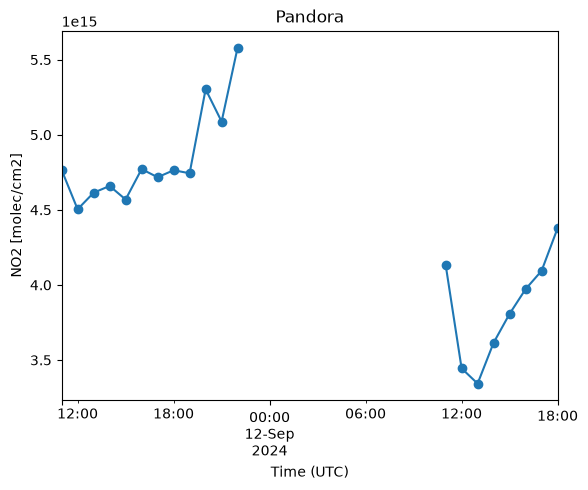

In [41]:
#plot pandora data
pancol = 'nitrogen_dioxide_vertical_column_amount'
px=pdf[pancol]
px.plot(ylabel='NO2 [molec/cm2]',title='Pandora',xlabel='Time (UTC)',marker='o')
None 
print(px)

0       6.010037e+15
1       6.205817e+15
2       6.041412e+15
3       6.025755e+15
4       5.881284e+15
            ...     
2774    4.316852e+15
2775    4.286139e+15
2776    4.344313e+15
2777    4.277166e+15
2778    4.353346e+15
Name: nitrogen_dioxide_vertical_column_amount, Length: 2779, dtype: float64


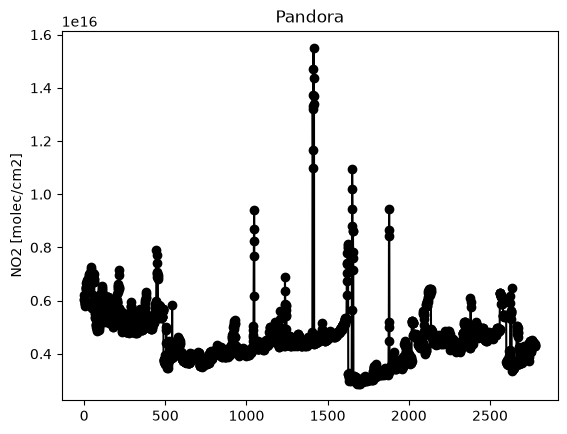

In [42]:
ppx = pdtf[pancol]
ppx.plot(ylabel='NO2 [molec/cm2]',title='Pandora',marker='o', color = 'k')
plt.gca() 
print(ppx)

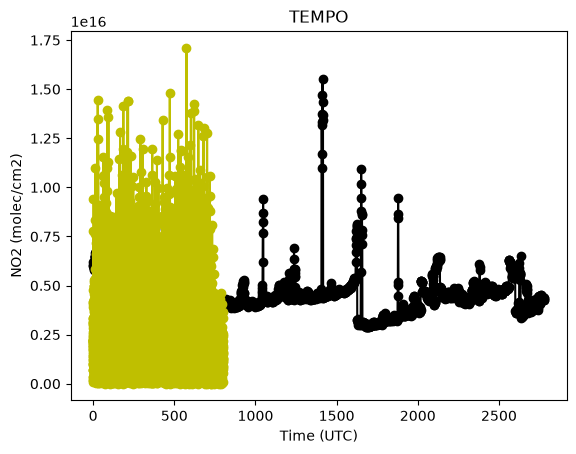

In [43]:
ppx = pdtf[pancol]
ppx.plot(ylabel='NO2 [molec/cm2]',title='Pandora',xlabel='Time (UTC)',marker='o', color = 'k')
nx.plot(ylabel='NO2 (molec/cm2)', title = 'TEMPO', xlabel='Time (UTC)', color='y',marker='o')
None 

time
2024-09-11 11:00:00+00:00    4.765805e+15
2024-09-11 12:00:00+00:00    4.503885e+15
2024-09-11 13:00:00+00:00    4.614120e+15
2024-09-11 14:00:00+00:00    4.659048e+15
2024-09-11 15:00:00+00:00    4.568916e+15
2024-09-11 16:00:00+00:00    4.771362e+15
2024-09-11 17:00:00+00:00    4.717225e+15
2024-09-11 18:00:00+00:00    4.763754e+15
2024-09-11 19:00:00+00:00    4.743752e+15
2024-09-11 20:00:00+00:00    5.303063e+15
2024-09-11 21:00:00+00:00    5.087863e+15
2024-09-11 22:00:00+00:00    5.580663e+15
2024-09-11 23:00:00+00:00             NaN
2024-09-12 00:00:00+00:00             NaN
2024-09-12 01:00:00+00:00             NaN
2024-09-12 02:00:00+00:00             NaN
2024-09-12 03:00:00+00:00             NaN
2024-09-12 04:00:00+00:00             NaN
2024-09-12 05:00:00+00:00             NaN
2024-09-12 06:00:00+00:00             NaN
2024-09-12 07:00:00+00:00             NaN
2024-09-12 08:00:00+00:00             NaN
2024-09-12 09:00:00+00:00             NaN
2024-09-12 10:00:00+00:00    

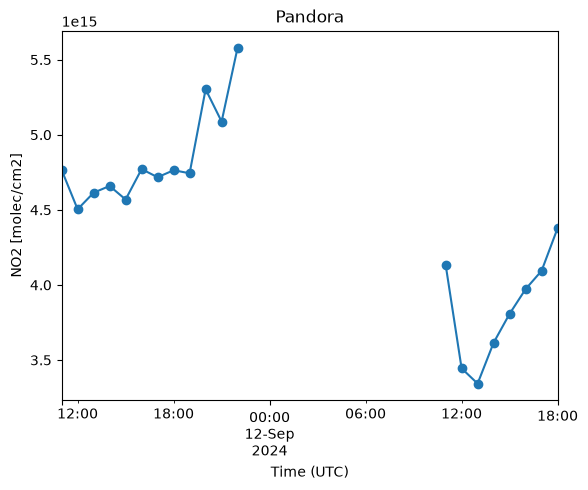

In [44]:
dx=pdf[pancol]
dx.plot(ylabel='NO2 [molec/cm2]',title='Pandora',xlabel='Time (UTC)',marker='o')
print(dx)
dx.to_csv('Pandora'+'_'+bdate[:10]+'_'+edate[:10]+bdate[11:13]+'h'+'_'+edate[11:13]+'h'+'.csv',mode='w')
None 

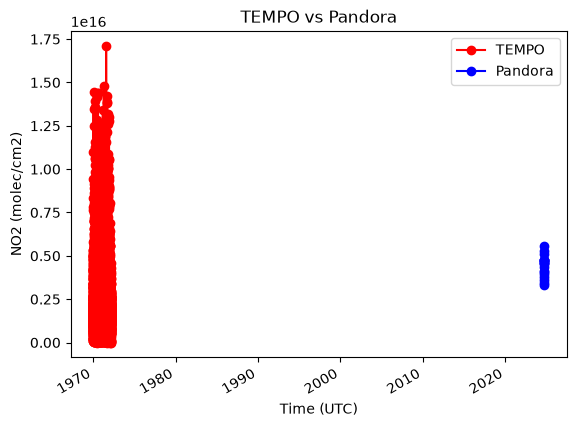

In [46]:
#plot TEMPO vs Pandora data (same units so dont worry about conversion)
nx.plot(title='TEMPO vs Pandora',ylabel= 'NO2 (molec/cm2)', label='TEMPO', marker='o', linestyle='-',color='r')
px.plot(label='Pandora', marker='o', linestyle='-',xlabel='Time (UTC)',color='b')
#dx.plot(label='Pandora', marker='o', linestyle='-',xlabel='Time (UTC)',color='b')
plt.legend()
None 

time
2024-09-11 10:00:00+00:00    17.00
2024-09-11 11:00:00+00:00    20.00
2024-09-11 12:00:00+00:00    15.00
2024-09-11 13:00:00+00:00    12.00
2024-09-11 14:00:00+00:00     5.05
2024-09-11 15:00:00+00:00     2.25
2024-09-11 16:00:00+00:00     1.80
2024-09-11 17:00:00+00:00     2.10
2024-09-11 18:00:00+00:00     2.15
2024-09-11 19:00:00+00:00     2.35
2024-09-11 20:00:00+00:00     3.35
2024-09-11 21:00:00+00:00     2.85
2024-09-11 22:00:00+00:00     3.40
2024-09-11 23:00:00+00:00     3.40
2024-09-12 00:00:00+00:00     6.85
2024-09-12 01:00:00+00:00     5.95
2024-09-12 02:00:00+00:00     7.60
2024-09-12 03:00:00+00:00     8.05
2024-09-12 04:00:00+00:00     6.80
2024-09-12 05:00:00+00:00     4.15
2024-09-12 07:00:00+00:00     3.00
2024-09-12 08:00:00+00:00     3.30
2024-09-12 09:00:00+00:00     6.20
2024-09-12 10:00:00+00:00    11.35
2024-09-12 11:00:00+00:00    12.45
2024-09-12 12:00:00+00:00     5.40
2024-09-12 13:00:00+00:00     1.75
2024-09-12 14:00:00+00:00     2.10
2024-09-12 15:0

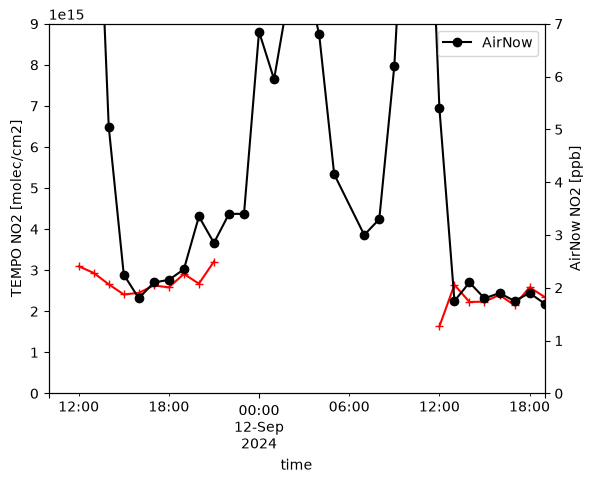

In [47]:
# Plot airnow vs TEMPO, different units, but don't worry, that is why we created the Pandora graph above
airnowno2 = adf['no2'].groupby(adf['time']).median()
ax = hdf[tempocol].plot(ylabel='TEMPO NO2 [molec/cm2]', color='r', marker='+', ylim=(0, 9e15), label = 'TEMPO')
airnowno2.plot(ax=ax.twinx(), color='k', marker='o', ylim=(0, 7), ylabel='AirNow NO2 [ppb]', label = 'AirNow')
plt.legend()
print(airnowno2)
None 

In [53]:
airnowno2.to_csv('Airnow'+'_'+bdate[:10]+'_'+edate[:10]+bdate[11:13]+'h'+'_'+edate[11:13]+'h'+'.csv',mode='w')

In [49]:
api.grid_kw
#Set up grid to be mapped, You can see resolution of regrid in GDNAM, in this case it is 1US1, to change, go to grid_kw in first few cells
#change to argument such as 4US1 if desired
#api.grid_kw['XCpELL'].replace('0.01')

{'GDNAM': 'GLOBAL',
 'GDTYP': 1,
 'NCOLS': 112,
 'NROWS': 87,
 'XORIG': -76.94,
 'YORIG': 36.53,
 'XCELL': 0.01,
 'YCELL': 0.01,
 'P_ALP': 0.0,
 'P_BET': 0.0,
 'P_GAM': 0.0,
 'XCENT': 0.0,
 'YCENT': 0.0,
 'VGTYP': 7,
 'VGTOP': 5000.0,
 'NLAYS': 35,
 'earth_radius': 6370000.0,
 'g': 9.81,
 'R': 287.04,
 'A': 50.0,
 'T0': 290,
 'P0': 100000.0,
 'REGRID_AGGREGATE': 'None',
 'REGRID': 'weighted'}

In [50]:
print(api.grid_kw)

{'GDNAM': 'GLOBAL', 'GDTYP': 1, 'NCOLS': 112, 'NROWS': 87, 'XORIG': -76.94, 'YORIG': 36.53, 'XCELL': 0.01, 'YCELL': 0.01, 'P_ALP': 0.0, 'P_BET': 0.0, 'P_GAM': 0.0, 'XCENT': 0.0, 'YCENT': 0.0, 'VGTYP': 7, 'VGTOP': 5000.0, 'NLAYS': 35, 'earth_radius': 6370000.0, 'g': 9.81, 'R': 287.04, 'A': 50.0, 'T0': 290, 'P0': 100000.0, 'REGRID_AGGREGATE': 'None', 'REGRID': 'weighted'}


In [51]:
'''
{'GDNAM': 'GLOBAL',
 'GDTYP': 1,
 'NCOLS': 15,
 'NROWS': 13,
 'XORIG': -77.0,
 'YORIG': 36.4,
 'XCELL': 0.1,
 'YCELL': 0.1,
 'P_ALP': 0.0,
 'P_BET': 0.0,
 'P_GAM': 0.0,
 'XCENT': 0.0,
 'YCENT': 0.0,
 'VGTYP': 7,
 'VGTOP': 5000.0,
 'NLAYS': 35,
 'earth_radius': 6370000.0,
 'g': 9.81,
 'R': 287.04,
 'A': 50.0,
 'T0': 290,
 'P0': 100000.0,
 'REGRID_AGGREGATE': 'None'}
 '''

"\n{'GDNAM': 'GLOBAL',\n 'GDTYP': 1,\n 'NCOLS': 15,\n 'NROWS': 13,\n 'XORIG': -77.0,\n 'YORIG': 36.4,\n 'XCELL': 0.1,\n 'YCELL': 0.1,\n 'P_ALP': 0.0,\n 'P_BET': 0.0,\n 'P_GAM': 0.0,\n 'XCENT': 0.0,\n 'YCENT': 0.0,\n 'VGTYP': 7,\n 'VGTOP': 5000.0,\n 'NLAYS': 35,\n 'earth_radius': 6370000.0,\n 'g': 9.81,\n 'R': 287.04,\n 'A': 50.0,\n 'T0': 290,\n 'P0': 100000.0,\n 'REGRID_AGGREGATE': 'None'}\n "

In [52]:
#build xarray data set for TEMPO NO2
ds = api.to_ioapi(tempokey)
ds

<xarray.Dataset> Size: 5MB
Dimensions:          (TSTEP: 34, VAR: 4, DATE-TIME: 2, LAY: 1, ROW: 87, COL: 112)
Coordinates:
  * TSTEP            (TSTEP) datetime64[ns] 272B 2024-09-11T10:00:00 ... 2024...
  * LAY              (LAY) float32 4B 0.9975
  * ROW              (ROW) float64 696B 0.5 1.5 2.5 3.5 ... 83.5 84.5 85.5 86.5
  * COL              (COL) float64 896B 0.5 1.5 2.5 3.5 ... 109.5 110.5 111.5
Dimensions without coordinates: VAR, DATE-TIME
Data variables:
    TFLAG            (TSTEP, VAR, DATE-TIME) int32 1kB ...
    LONGITUDE        (TSTEP, LAY, ROW, COL) float32 1MB ...
    LATITUDE         (TSTEP, LAY, ROW, COL) float32 1MB ...
    COUNT            (TSTEP, LAY, ROW, COL) int32 1MB ...
    NO2_VERTICAL_CO  (TSTEP, LAY, ROW, COL) float32 1MB ...
Attributes: (12/34)
    IOAPI_VERSION:  1.0 1997349 (Dec. 15, 1997)
    EXEC_ID:        ????????????????                                         ...
    FTYPE:          1
    CDATE:          2026275
    CTIME:          1807
    WDATE:          2026275
    ...             ...
    GDNAM:          M_02_99BRACE    
    UPNAM:          XDRConvert      
    VAR-LIST:       LONGITUDE       LATITUDE        COUNT           NO2_VERTI...
    FILEDESC:       https://tempo.si.edu/,TEMPOSubset,XDRConvert             ...
    HISTORY:        XDRConvert
    crs_proj4:      +proj=lonlat +R=6370000.0

In [54]:
# approximate coordinate difference 

In [55]:
# Choose a column from above, notice that names are truncated, so they can be weird
tempoikey = 'NO2_VERTICAL_CO'
long = "LONGITUDE"
lati = "LATITUDE"

In [56]:
ds[long]

<xarray.DataArray 'LONGITUDE' (TSTEP: 34, LAY: 1, ROW: 87, COL: 112)> Size: 1MB
[331296 values with dtype=float32]
Coordinates:
  * TSTEP    (TSTEP) datetime64[ns] 272B 2024-09-11T10:00:00 ... 2024-09-12T1...
  * LAY      (LAY) float32 4B 0.9975
  * ROW      (ROW) float64 696B 0.5 1.5 2.5 3.5 4.5 ... 82.5 83.5 84.5 85.5 86.5
  * COL      (COL) float64 896B 0.5 1.5 2.5 3.5 4.5 ... 108.5 109.5 110.5 111.5
Attributes:
    units:      deg
    long_name:  LONGITUDE       
    var_desc:   Longitude at the center of each grid cell                    ...

In [57]:
ds.coords['COL'] = ds.COL.data * ds.XCELL + ds.XORIG
ds.coords['ROW'] = ds.ROW.data * ds.YCELL + ds.YORIG

/opt/anaconda3/envs/earth-analytics-python/lib/python3.11/site-packages/pycno/__init__.py:538: UserWarning: Downloading: https://www.giss.nasa.gov/tools/panoply/overlays/MWDB_Coasts_NA_1.cnob to /Users/davidwilcox/.pycno/MWDB_Coasts_NA_1.cnob
  warnings.warn('Downloading: ' + url + ' to ' + str(datapatho))


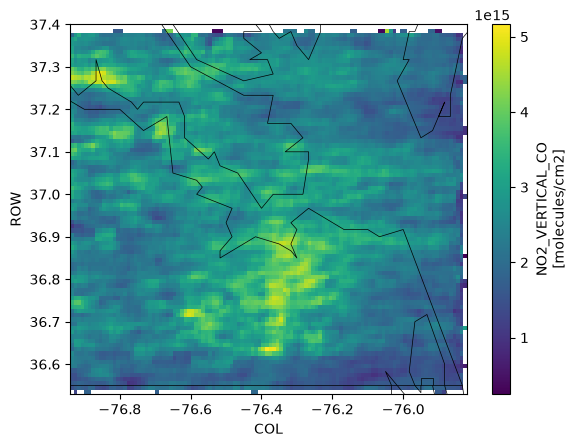

In [58]:
# Now plot a map
cno = pycno.cno(ds.crs_proj4)
qm = ds[tempoikey].where(lambda x: x>0).mean(('TSTEP', 'LAY')).plot()
cno.drawstates(resnum=1)

In [59]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rasterio
from rasterio.transform import from_origin

In [60]:
import rasterio
from rasterio.transform import Affine
import numpy as np

#define georeference points
bottom_left = (-76.930934959, 36.550312014)  # (longitude, latitude)
top_right = (-75.86753207, 37.371761969)  # (longitude, latitude)

#get dimensions
width = ds.sizes['COL']
height = ds.sizes['ROW']

xres = (top_right[0] - bottom_left[0]) / width
yres = (top_right[1] - bottom_left[1]) / height 

#affine transform using bottom left as reference
transform = Affine.translation(bottom_left[0], bottom_left[1]) * Affine.scale(xres, yres)


crs = "EPSG:4326"


data = ds[tempoikey].where(lambda x: x > 0).mean(('TSTEP', 'LAY')).values

#data = np.fliplr(data)

output_path = ('TEMPO_NO2' + bdate[:10] +'_'+bdate[11:13]+'h'+'_'+edate[11:13]+'h'+'.tif')

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=data.shape[0],
    width=data.shape[1],
    count=1,
    dtype=data.dtype,
    crs=crs,
    transform=transform,
) as dst:
    dst.write(data, 1)

print(f"GeoTIFF saved to {output_path}")

GeoTIFF saved to TEMPO_NO22024-09-11_10h_19h.tif
